# Exploração

**Maj Diego / 2º semestre de 2026**

**Objetivos**

1. Comparar o SLAM 100 com um Scanner homólogo 
2. Explicar a pasta de dados proprietários de um levantamento via SLAM 100


## 1. X120 vs SLAM100

| <a href="media/manuais/X120GO_UserGuide_ENG.pdf">STONEX X120</a>  |  <a href="media/manuais/Slam 100 product manual.pdf">FEIMA ROBOTICS SLAM 100</a>|
|-|-|
|Origem: Italiano<br>Laser Scanning FOV: 270°×360° <br> Camera FOV: 200° ( H ) x 100° ( V )<br> Absolute Accuracy: 5cm  <br> Laser Pulse Repetition Rate: 320kHz <br>Maximum Range: 120m <br>Camera Resolution: 5MP <br>Weight: 1,6Kg <br> Laser channels: 16<br> WIFI Password: 12345678<br>App: GOApp| Origem: Chinês <br>Laser Scanning FOV: 270°×360° <br> Camera FOV: 200° ( H ) x 100° ( V )<br> Absolute Accuracy: 5cm  <br> Laser Pulse Repetition Rate: 320kHz <br>Maximum Range: 120m <br>Camera Resolution: 5MP <br>Weight: 1,6Kg <br> Laser channels: 16<br> WIFI Password: 12345678<br> App: SLAM GO|
|<center><img src="media/imgs/arquivos_raw_x120go.jpeg"></center> | <center><img src="media/imgs/arquivos_raw_slam100.jpg"></center> |
|<center><img src="media/imgs/x120go_home.png"></center> | <center><img src="media/imgs/slamgo_home.jpeg"></center> |
|**4.1 How to use X120GO without application** <br> • Turn on the scanner by pressing the power button for a couple of seconds and wait for the LiDAR head to start rotating.<br> • Place the scanner in a stable spot for initialisation. Press the power button once quickly. The green LED will start flashing indicating that the instrument is acquiring data correctly. <br> • Wait one minute for the instrument to initialise. Make sure that there are no persons or objects moving in front nearby.<br> • After one minute has passed, begin acquisition normally.<br> • If you wish to acquire a control point, place the scanner over a target or recognisable point and stand over this point for at least 10 seconds. After 10 seconds resume scanning normally.<br> • To end the scan, press the power button once quickly. The green LED will stop flashing, indicating the end of data acquisition. | **Device power on** <br> • Press the scanner on key for 3 seconds for a long time, and the status indicator light is always green (the battery is fully charged). Wait for the laser head to start rotating, and then the device starts successfully.<br>  **Start collecting** <br> • Press the scanner on key, and the data acquisition function will be turned on. At this time, the status indicator will turn green (the battery is fully charged) and blink.|
|**API**: Não informado | **API** (https://wiki.feima.cool/en/sdk/slam/http):  <br> • Starting the Device: <br> ••  <code>curl --location --request GET 'http://192.168.10.1:19700/slam/start_work'</code> <br> • Status Check Command: <br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam/get_error_status'</code>  <br> • Stopping the Device:  <br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam/end_work'</code> <br>• Get SSD Info:<br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam2000/get_ssd_info'</code> <br> • Get Real-Time Mapping Status:<br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam/get_mapping_info'</code> <br> • Get Battery State <br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam2000/get_battery_state'</code> <br> • Set Motor Speed <br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam2000/set_motor_speed?speed=[float32]'</code> <br> • Get Motor Status <br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam2000/get_motor_board_state'</code>  |
|<center><img src="media/imgs/outdoorstonex.jpeg"><center>|<center><img src="media/imgs/outdoorfeima.jpeg"><center>|

## 2. Pasta de dados de um levantamento

In [3]:
# Coloque a pasta de dados SN_00007 uma pasta acima do diretório atual:
import os
print(os.listdir(".."))
dados_dir = "../SN_00007/PROJ1"

['app SLAM GO', 'exported', 'git', 'IME_lidar', 'jadx-1-5-3', 'SlamProject', 'SN_00007', 'SN_00007.zip', 'SN_00008', 'SN_00010', 'SN_00011', 'SN_00014', 'SN_00015', 'SN_00017', 'SN_00040', 'SN_00040.zip', 'SN_00041', 'SN_00042', 'SN_00043', 'SN_00044', 'SN_00045', 'SN_00046', 'SN_00047', 'SN_00048', 'SN_00049', 'SN_00055', 'SN_00055.zip', 'table_scanner.html']


In [4]:
# O que tem dentro da pasta de dados?
os.listdir(dados_dir)

['241023-122500_00007_IMU_DATA_0001.txt',
 '241023-122500_00007_RASTER_DATA_0001.txt',
 '241023-122500_00007_SLAM_Pandar_0001_0.pcap',
 'camera0',
 'camera1',
 'camera2',
 'feima_slam100_calib.yaml',
 'task_info.txt']

In [5]:
pcap_file = [f for f in os.listdir(dados_dir) if f.endswith(".pcap")][0]
second_platform_file = [f for f in os.listdir(dados_dir) if "RASTER" in f.upper()][0]
imu_file = [f for f in os.listdir(dados_dir) if "_IMU" in f.upper()][0]
calibration_file = [f for f in os.listdir(dados_dir) if "_CALIB" in f.upper()][0]
pcap_file, second_platform_file, imu_file, calibration_file

('241023-122500_00007_SLAM_Pandar_0001_0.pcap',
 '241023-122500_00007_RASTER_DATA_0001.txt',
 '241023-122500_00007_IMU_DATA_0001.txt',
 'feima_slam100_calib.yaml')

#### 2.1 As imagens das 3 câmeras

Quantidade de frames da câmera 3: 218
Quantidade de frames da câmera 1: 218
Quantidade de frames da câmera 2: 218
Câmera 1 - 1ª img: cam1_pic0_Wednesday-12-26-56-909443.jpeg:


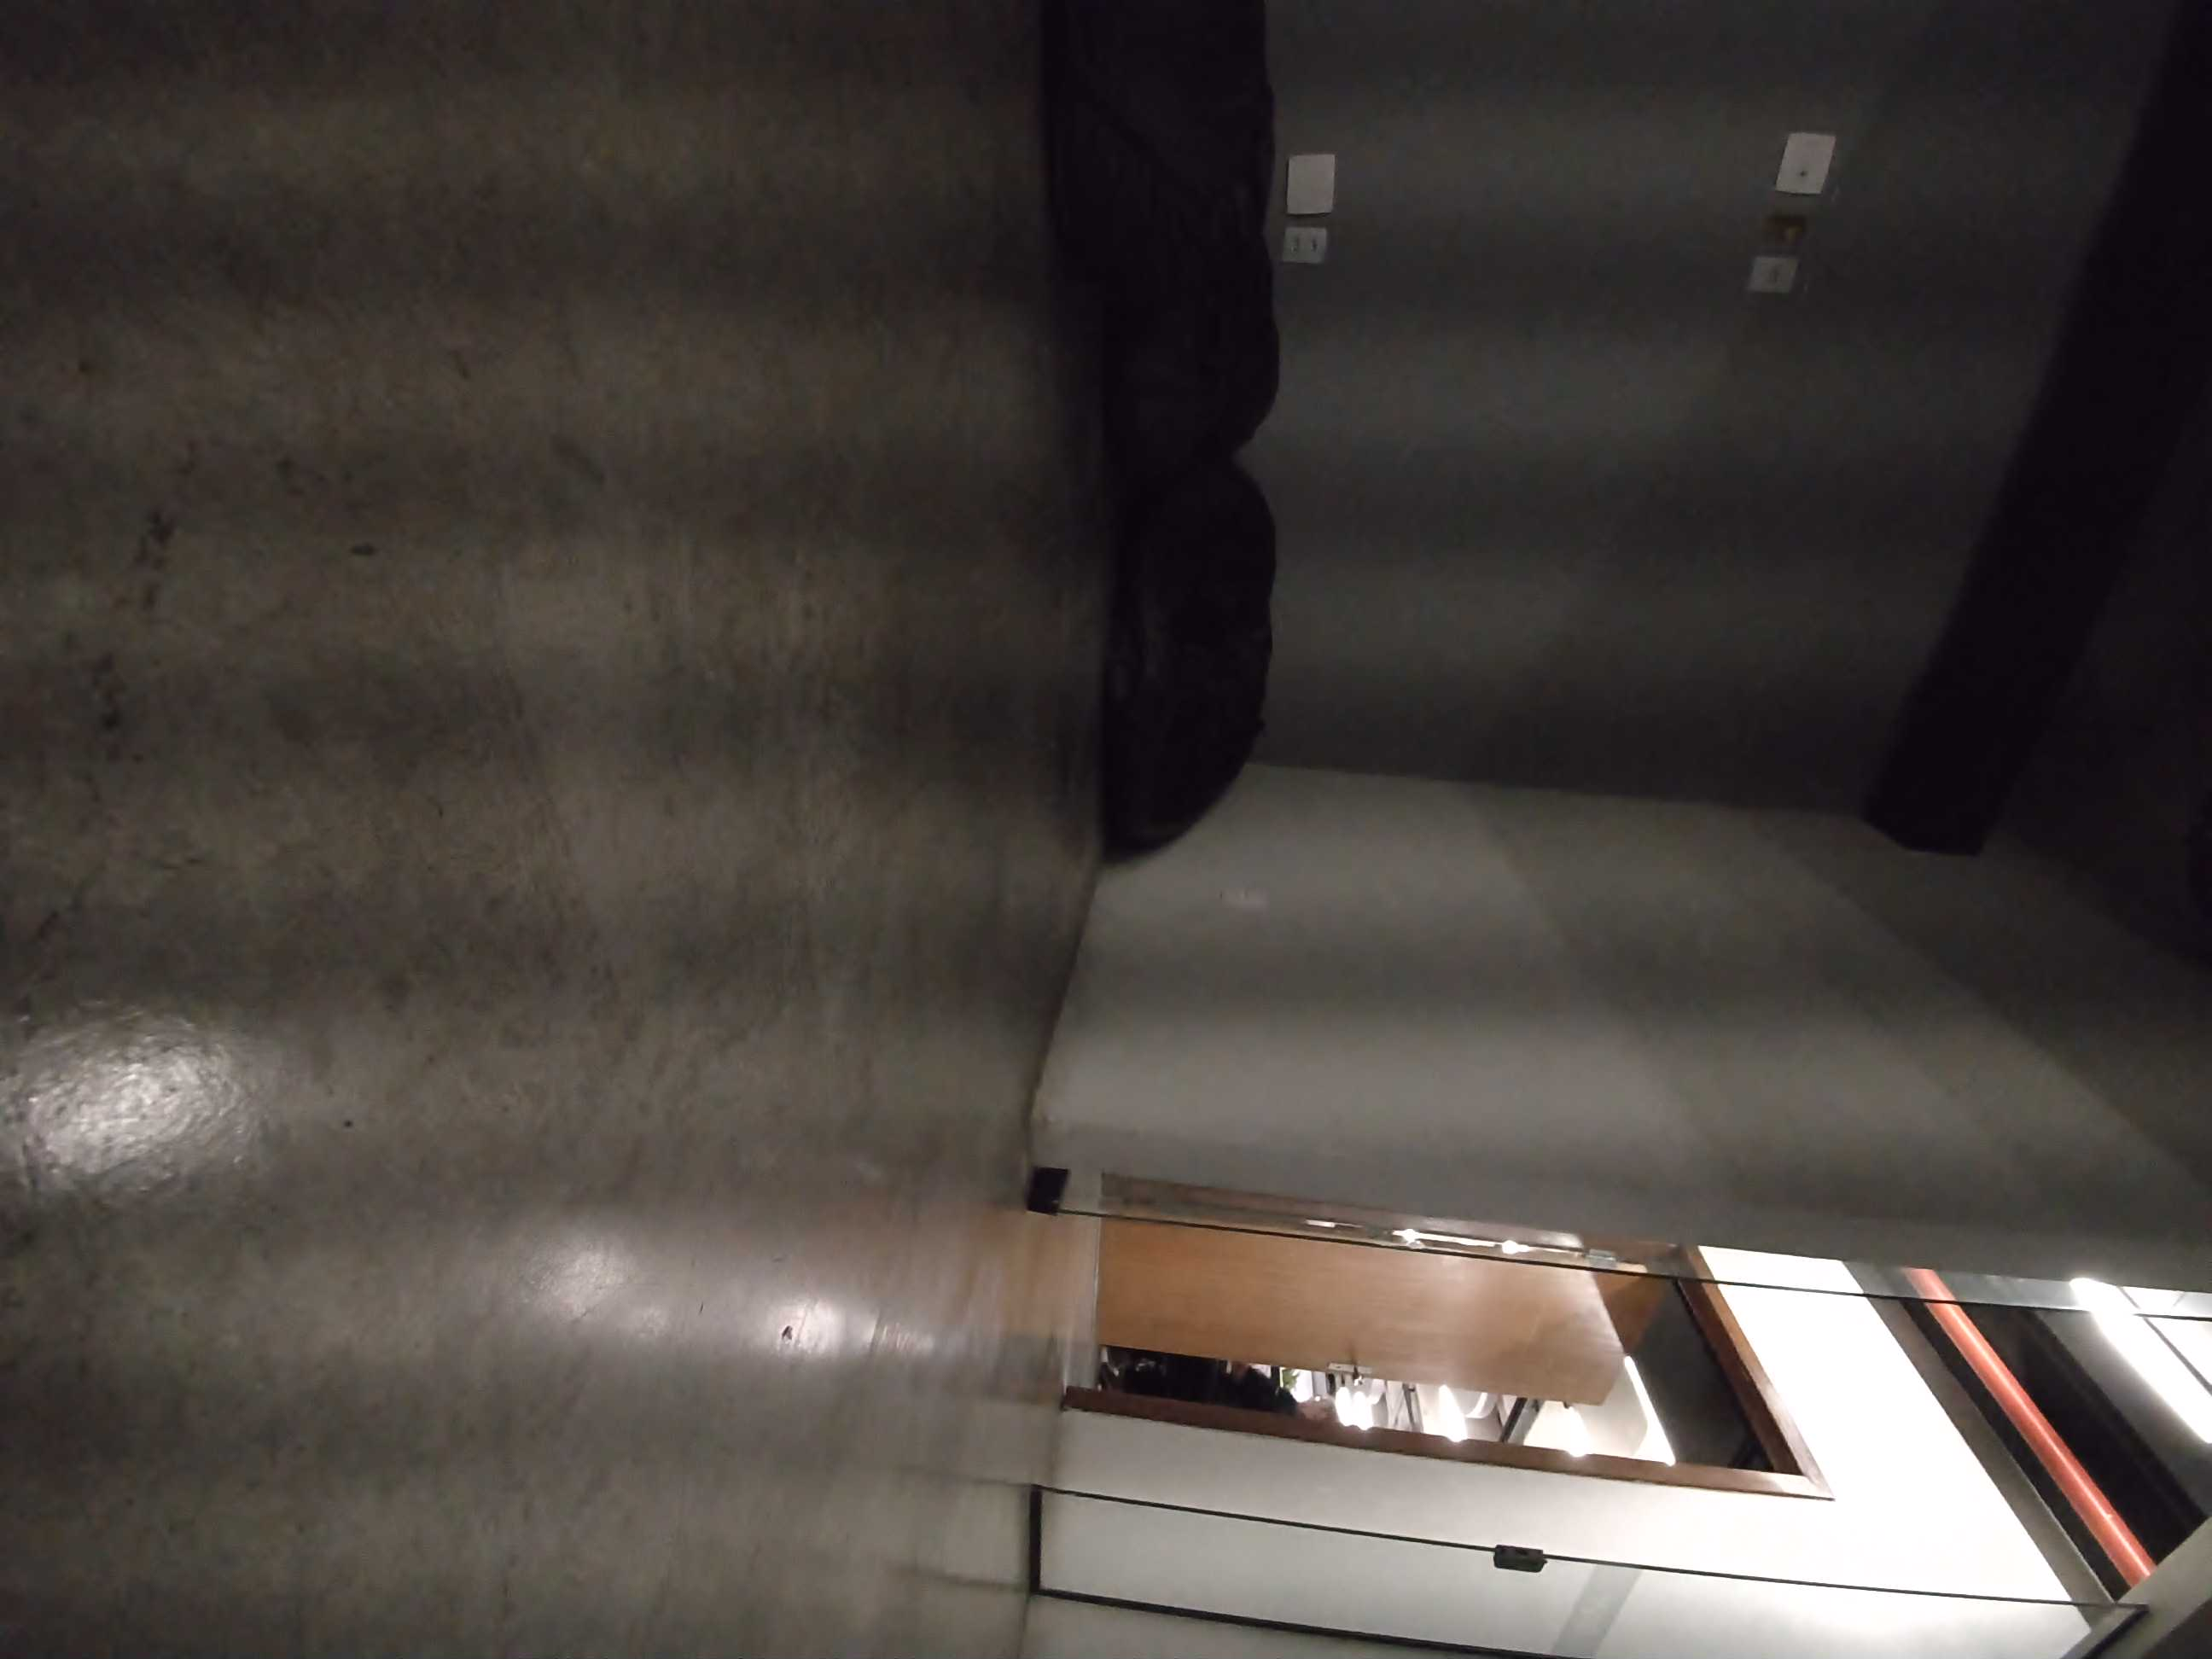

In [6]:
frames0 = os.listdir(os.path.join(dados_dir, "camera0"))
print("Quantidade de frames da câmera 3:", len(frames0))
frames1 = os.listdir(os.path.join(dados_dir, "camera1"))
print("Quantidade de frames da câmera 1:", len(frames1))
frames2 = os.listdir(os.path.join(dados_dir, "camera2"))
print("Quantidade de frames da câmera 2:", len(frames2))

# Abrindo a primeira imagem da câmera 1
from PIL import Image
print(f"Câmera 1 - 1ª img: {frames1[0]}:")
image_path = os.path.join(dados_dir, "camera1", frames1[0])
image = Image.open(image_path)
image

#### 2.2 O Arquivo "RASTER"

In [7]:
# Ler o arquivo de segunda plataforma giratória (RASTER)
print(second_platform_file)
l =10
with open(os.path.join(dados_dir, second_platform_file), "r") as f:
    for line in f.readlines():
        print(line, end="")
        l -= 1
        if l == 0:
            break

241023-122500_00007_RASTER_DATA_0001.txt
SAMPTIME    	DIR         INC         ANGLE       NUM         
304015.655487,0,224,39.375000,52
304015.656362,0,225,39.550781,52
304015.657238,0,226,39.726562,52
304015.658127,0,227,39.902344,52
304015.659017,0,228,40.078125,52
304015.659905,0,229,40.253906,52
304015.660816,0,230,40.429688,52
304015.661758,0,231,40.605469,52
304015.662689,0,232,40.781250,52


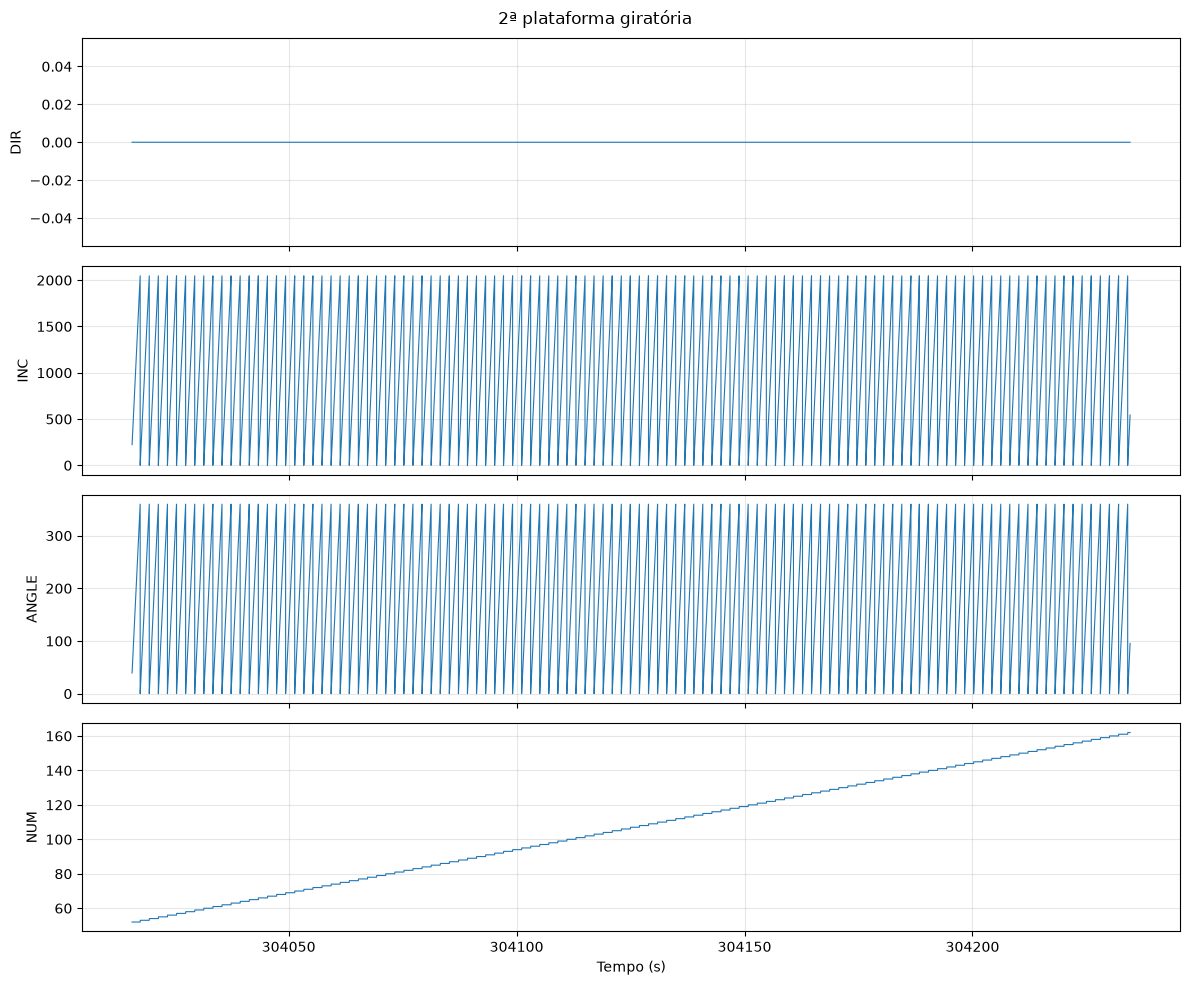

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raster_columns = ["SAMPTIME", "DIR", "INC", "ANGLE", "NUM"]
raster_data = pd.read_csv(
    os.path.join(dados_dir, second_platform_file),
    skiprows=1, names=raster_columns
)
raster_data = raster_data.apply(pd.to_numeric, errors="coerce").dropna()
raster_variables = raster_columns[1:]

fig, axes = plt.subplots(len(raster_variables), 1, figsize=(12, 10), sharex=True)
for ax, variable in zip(axes, raster_variables):
    ax.plot(raster_data["SAMPTIME"], raster_data[variable], linewidth=0.8)
    ax.set_ylabel(variable)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Tempo (s)")
fig.suptitle("2ª plataforma giratória")
fig.tight_layout()
plt.show()

Dados de ângulos cíclicos condizendo com o esperado. Qual a frequência?

,SAMPTIME,DIR,INC,ANGLE,NUM
0,304015.655487,0,224,39.375,52
2048,304017.648388,0,224,39.375,53
4096,304019.642620,0,224,39.375,54
6144,304021.637134,0,224,39.375,55
8192,304023.631791,0,224,39.375,56


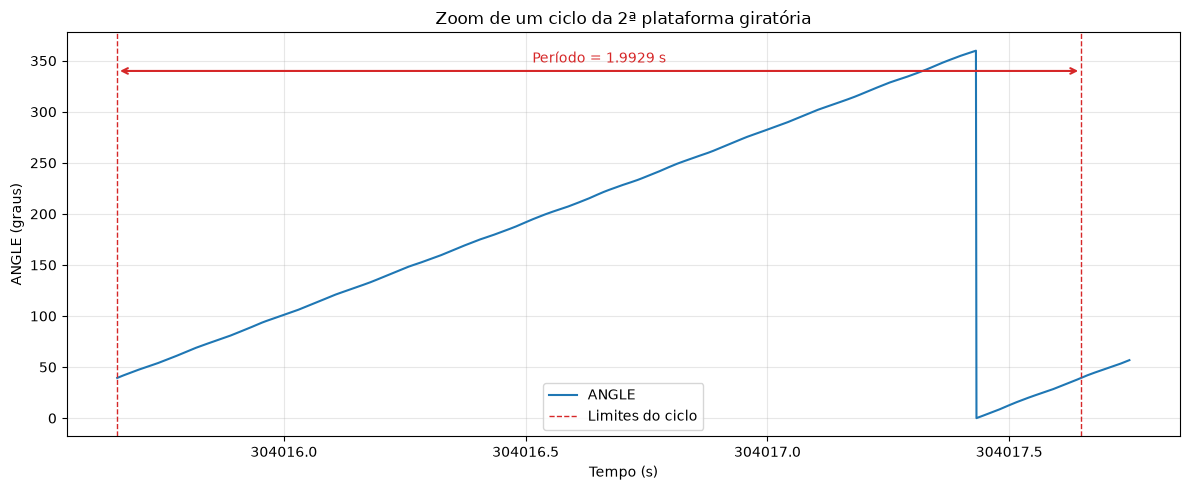

Período do ciclo: 1.992901 s
Frequência: 30.106864 RPM


In [9]:
from IPython.display import display
from matplotlib.ticker import FuncFormatter

# Cada queda de aproximadamente 360° para 0° marca o início de um novo ciclo.
angle_values = raster_data["ANGLE"].to_numpy()

cycle_start = angle_values[0]
angle_cycle_loop = raster_data.loc[raster_data["ANGLE"]==cycle_start].copy()
display(angle_cycle_loop.head())
cycle_start_time = angle_cycle_loop["SAMPTIME"].iloc[0]
cycle_end_time = angle_cycle_loop["SAMPTIME"].iloc[1]
cycle_period_s = cycle_end_time - cycle_start_time
cycle_frequency_hz = 1.0 / cycle_period_s
cycle_frequency_RPM = cycle_frequency_hz *60

df_one_loop = raster_data.iloc[angle_cycle_loop.index[0]:angle_cycle_loop.index[1]+100]
fig, ax = plt.subplots(figsize=(12, 5))
df_one_loop.plot(x="SAMPTIME", y="ANGLE", color="tab:blue", linewidth=1.5, ax=ax)

ax.axvline(cycle_start_time, color="tab:red", linestyle="--", linewidth=1, label="Limites do ciclo")
ax.axvline(cycle_end_time, color="tab:red", linestyle="--", linewidth=1)
ax.annotate(
    "", xy=(cycle_start_time, 340), xytext=(cycle_end_time, 340),
    arrowprops={"arrowstyle": "<->", "color": "tab:red", "linewidth": 1.5},
)
ax.text(
    cycle_start_time+ cycle_period_s / 2, 345,
    f"Período = {cycle_period_s:.4f} s",
    ha="center", va="bottom", color="tab:red",
)

ax.set(
    title="Zoom de um ciclo da 2ª plataforma giratória",
    xlabel="Tempo (s)",
    ylabel="ANGLE (graus)",
)

def formatter(x, pos):
    return f'{x}'

ax.xaxis.set_major_formatter(FuncFormatter(formatter))

ax.grid(alpha=0.3)
ax.legend(loc="lower center")
plt.tight_layout()
plt.show()

print(f"Período do ciclo: {cycle_period_s:.6f} s")
print(f"Frequência: {cycle_frequency_RPM:.6f} RPM")

#### 2.3 O Arquivo "IMU"

In [10]:
# Ler o arquivo do sensor inercial (IMU)
print(imu_file)
l =10
with open(os.path.join(dados_dir, imu_file), "r") as f:
    for line in f.readlines():
        print(line, end="")
        l -= 1
        if l == 0:
            break

241023-122500_00007_IMU_DATA_0001.txt
SAMPTIME    	ACCX        ACCY        ACCZ        GYRX        GYRY        GYRZ        Q0          Q1          Q2          Q3          
304015.593015,-1.187655,0.021507,9.878807,-0.003725,0.021817,-0.003725,0.998307,-0.000000,0.000000,-0.000000
304015.594015,-1.354931,0.140989,9.066326,-0.004789,0.006917,-0.006385,0.998312,0.000115,0.001103,-0.000000
304015.595015,-1.135083,0.172055,9.506021,0.000532,-0.005321,-0.006917,0.998310,0.000247,0.001970,-0.000000
304015.596015,-1.027549,0.186393,10.072369,0.005321,0.004789,-0.003193,0.998309,0.000380,0.002697,-0.000000
304015.597015,-1.276072,0.109924,9.728259,0.007450,0.013835,0.006917,0.998306,0.000458,0.003626,-0.000000
304015.598015,-1.412282,-0.038234,9.711532,0.008514,-0.000532,0.014899,0.998301,0.000423,0.004645,-0.000001
304015.599015,-1.142252,-0.093196,10.304164,0.009578,-0.004257,0.015963,0.998298,0.000349,0.005396,-0.000001
304015.600015,-0.977366,-0.054962,10.151227,0.007982,0.009578,0.015963,0

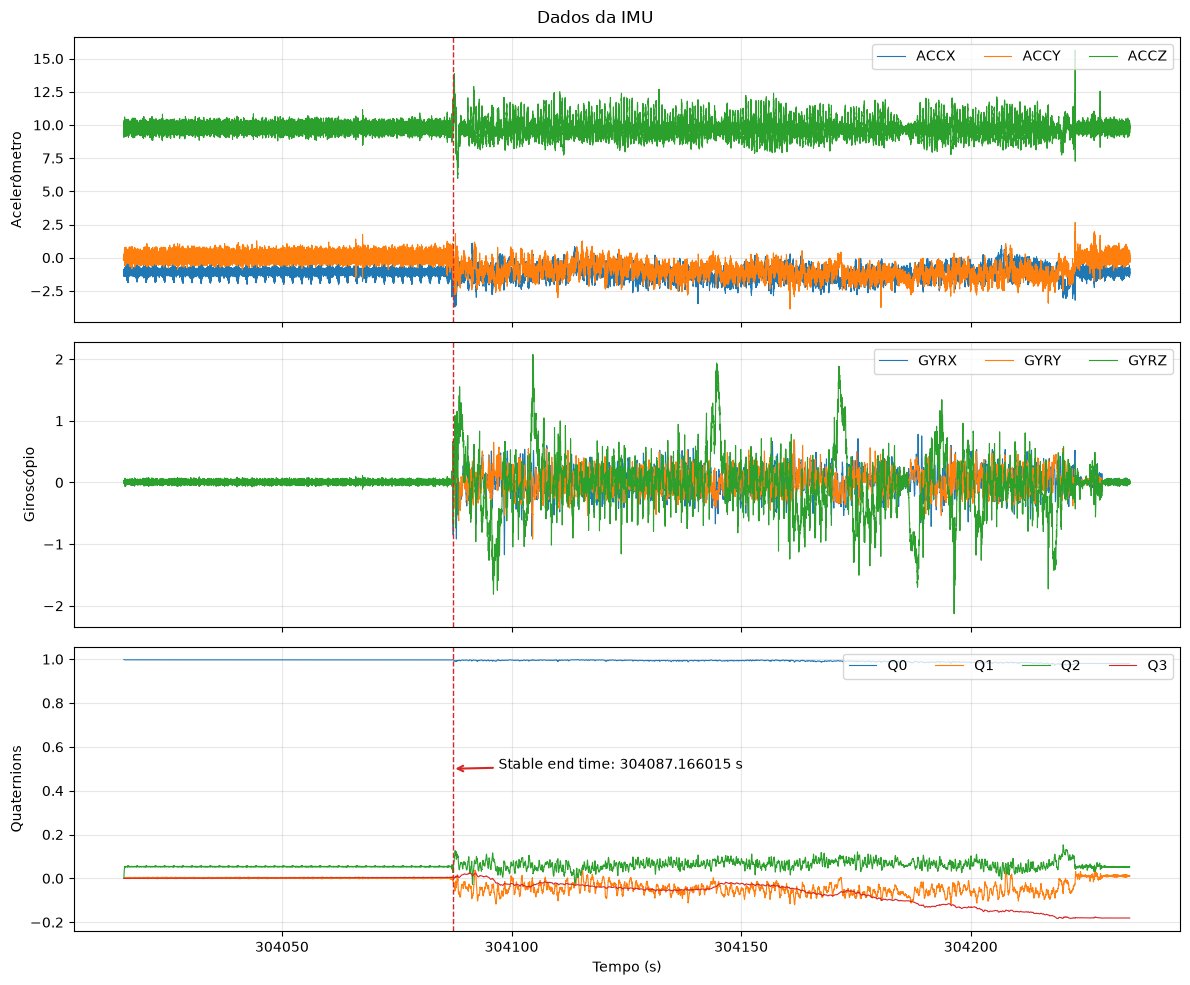

In [23]:
imu_columns = [
    "SAMPTIME", "ACCX", "ACCY", "ACCZ",
    "GYRX", "GYRY", "GYRZ", "Q0", "Q1", "Q2", "Q3"
]
imu_data = pd.read_csv(
    os.path.join(dados_dir, imu_file),
    skiprows=1, names=imu_columns
)
imu_data = imu_data.apply(pd.to_numeric, errors="coerce").dropna()
imu_groups = {
    "Acelerômetro": ["ACCX", "ACCY", "ACCZ"],
    "Giroscópio": ["GYRX", "GYRY", "GYRZ"],
    "Quaternions": ["Q0", "Q1", "Q2", "Q3"],
}

# Identificar o maior período contínuo em que a IMU permaneceu estável.
gyro_variables = ["GYRX", "GYRY", "GYRZ"]
gyro_norm = np.sqrt(imu_data[gyro_variables].pow(2).sum(axis=1))
sample_interval_s = imu_data["SAMPTIME"].diff().median()
stability_window = max(1, round(1.0 / sample_interval_s))
smoothed_gyro_norm = gyro_norm.rolling(
    window=stability_window, center=True, min_periods=1
).median()

# Valores abaixo deste limiar indicam ausência de rotação relevante.
gyro_stability_threshold = 0.10
stable_mask = smoothed_gyro_norm < gyro_stability_threshold
stable_block = stable_mask.ne(stable_mask.shift()).cumsum()
stable_segments = (
    imu_data.loc[stable_mask]
    .groupby(stable_block.loc[stable_mask])["SAMPTIME"]
    .agg(start="first", end="last")
)
stable_segments["duration"] = stable_segments["end"] - stable_segments["start"]
stable_start_time, stable_end_time = stable_segments.loc[
    stable_segments["duration"].idxmax(), ["start", "end"]
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, (group_name, variables) in zip(axes, imu_groups.items()):
    for variable in variables:
        ax.plot(imu_data["SAMPTIME"], imu_data[variable], label=variable, linewidth=0.8)
    ax.set_ylabel(group_name)
    ax.axvline(stable_end_time, color="tab:red", linestyle="--", linewidth=1)

    ax.legend(ncol=len(variables), loc="upper right")
    ax.grid(alpha=0.3)

ax.annotate(
    f"Stable end time: {stable_end_time} s", xy=(stable_end_time, 0.5), xytext=(stable_end_time+10, 0.5),
    arrowprops={"arrowstyle": "->", "color": "tab:red", "linewidth": 1.5},
)

axes[-1].set_xlabel("Tempo (s)")
fig.suptitle("Dados da IMU")
fig.tight_layout()
plt.show()


In [24]:
print(f"Stable end time: {stable_end_time} s")

Stable end time: 304087.166015 s


#### 2.3 A captura UDP dos dados LiDAR `.pcap`

https://www.hesaitech.com/downloads/#xt32-16

Requisitos:
- WireShark
- [Pandar View 2](https://hesaitechnology.github.io/dev/docs/how_to_guides/PandarView/)
- [Python pypcapkit](https://jarryshaw.github.io/PyPCAPKit/)

#### 2.2.1 Wireshark

![alt text](media/imgs/ws.png)

#### 2.2.2 Pandar view

![alt text](media/imgs/pandar.png)

#### 2.2.3 Python pcapkit

In [6]:
from pcapkit import extract
import os
# Extract packets from a PCAP file
pcap_file = os.path.join(dados_dir, pcap_file)
with extract(fin=pcap_file, auto=False, store=False, nofile=True, engine="default") as capture:
    for frame in capture:
        if "UDP" not in frame:
            continue

        udp = frame["UDP"]
        first_payload = udp.packet.payload
        break

In [7]:
from pprint import pprint
print("First UDP payload:",len(first_payload), "bytes")
pprint(first_payload)

First UDP payload: 568 bytes
(b'\xee\xff\x06\x01\x00\x00\x10\x08\x00\x04\x02\x01\xcd_\t\x03\x1c\xff\x08\x03'
 b'\x1f\xff\x06\x03\x1c\xff\x07\x03\x1c\xff\x05\x03\x19\xff\x08\x03'
 b'\x1c\xff\x0b\x03\x1d\xff\x0e\x03\x1c\xff\x13\x03\x1e\xff\x17\x03'
 b'\x1a\xff\x1e\x03\x1b\xff$\x03\x19\xff+\x03\x17\xff6\x03\x17\xffB\x03'
 b'\x18\xffL\x03\x18\xff\xdf_\x08\x03\x1d\xff\x07\x03\x1f\xff\x05\x03\x1b\xff'
 b'\x04\x03\x1c\xff\x05\x03\x1a\xff\x08\x03\x1c\xff\t\x03\x1c\xff\r\x03\x1c\xff'
 b'\x11\x03\x1d\xff\x17\x03\x19\xff\x1d\x03\x1a\xff"\x03\x19\xff+\x03\x19\xff'
 b'5\x03\x17\xff@\x03\x19\xffM\x03\x18\xff\xf1_\x07\x03\x1d\xff\x06\x03'
 b'\x1e\xff\x03\x03\x1d\xff\x04\x03\x1b\xff\x02\x03\x1b\xff\x07\x03'
 b'\x1c\xff\x08\x03\x1d\xff\x0c\x03\x1c\xff\x12\x03\x1e\xff\x15\x03'
 b'\x1b\xff\x1d\x03\x1a\xff!\x03\x19\xff(\x03\x18\xff4\x03\x17\xff=\x03'
 b'\x19\xffL\x03\x18\xff\x03`\x06\x03\x1d\xff\x04\x03\x1e\xff\x03\x03\x1c\xff'
 b'\x02\x03\x1b\xff\x01\x03\x19\xff\x05\x03\x1b\xff\x07\x03\x1c\xff'
 b'\x0c\x

**Mas o que significam esses bytes? Sabe-se que as informações LiDAR estão aí dentro!**

#### 2.2.4 LiDAR <a href="media/manuais/PandarXT-16_User_Manual_X02-en-250810.pdf">Pandar XT16</a>: 16-Channel Mid-Range Mechanical Lidar

**Specs:**
- Number of channels 16
- Instrumented range 0.05 to 120 m
- Horizontal FOV 360°
- Vertical FOV 30° (-15° to +15°)
- Vertical resolution 2°

**Ângulo vertical:**
<center><img src="media/imgs/pandar_xt16_channel_vertical_distribution.png" width=600></center>

In [8]:
import numpy as np
PANDAR_XT16_ELEVATION_DEG = np.arange(15.0, -16.0, -2.0)
PANDAR_XT16_ELEVATION_DEG

array([ 15.,  13.,  11.,   9.,   7.,   5.,   3.,   1.,  -1.,  -3.,  -5.,
        -7.,  -9., -11., -13., -15.])

**Data structure:** 

https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=49

<center><img src="media/imgs/pandar_xt16_data_structure.png" width=600></center>

<center><img src="media/imgs/pandar_xt15_pre-header.jpeg"></center>

**Distância e ângulo horizontal (azimute):**

<center><img src="media/imgs/pandar_xt16_axis.png" ></center>

<center><img src="media/imgs/pandar_xt16_body.png" width=600></center>

<center><img src="media/imgs/pandar_xt15_each_point_calc.jpeg" width=600></center>

Data point $p = [x \ y \ z]^T$

$$x =  distance_{horizontal} \times \sin{\alpha} \\
y = distance_{horizontal} \times \cos{\alpha} \\
z = distance \times \sin{\beta}$$

Onde $\alpha$ é o ângulo horizontal, $\beta$ é o ângulo vertical e $distance_{horizontal} = distance \times \cos(\beta)$.

<center><img src="media/imgs/pandar_xt16_tail.png" ></center>

Temos o **Timestamp** $t_0$ do pacote de dados e temos o **azimute** de um bloco, mas o manual fala que o ângulo horizontal ($\alpha$) deve ser corrigido, pois cada bloco dispara em sequência e, por sua vez, dentro de um bloco, cada canal dispara em sequência e não ao mesmo tempo, assim incorporando um pequeno atraso a depender do bloco e do canal:

$\alpha =  \text{azimute} + \underbrace{\text{deslocamento angular devido ao tempo de disparo}}_{ yaw(\kappa) =  \text{ velocidade angular de rotação } (w) \text{ em °/s } \times \text{ tempo de espera de disparo do laser } (t_m + t_n)}$

A velocidade angular de rotação é dada em RPM, em °/s é:

$w = RPM \times 6$

Cada um dos 8 blocos dispara a cada 50 $\mu s$ de modo que o tempo de disparo do laser de cada bloco em função do tempo do pacore $t_0$ é:

$t_m = t_0 - 50(8-m)$ onde $m$ é o número do bloco.

Dentro de cada bloco de disparos, o laser nos 16 canais são disparados conforme a fórmula:

$t_n = 5.632 + 3.024(n-1) + 0.368$ onde $n$ é o número do canal.

In [46]:
# Ler o PCAP com pypcapkit e decodificar os pacotes UDP do Hesai PandarXT-16
from datetime import datetime, timedelta, timezone
import struct

import numpy as np
import pandas as pd
from pcapkit import extract

# Angulos verticais nominais dos canais 1 a 16 (manual do PandarXT-16).
# Para maior exatidao, substitua-os pelos valores do arquivo de correcao
# angular que acompanha especificamente este sensor.
PANDAR_XT16_RETURN_NAMES = {
    0x33: ("first",),
    0x37: ("strongest",),
    0x38: ("last",),
    0x39: ("last", "strongest"),
    0x3B: ("last", "first"),
    0x3C: ("first", "strongest"),
}

def segundos_desde_domingo_utc(dt: datetime):
    # 0 para Segunda, ..., 6 para Domingo
    # (6 + 1) % 7 = 0 para Domingo
    dias_desde_domingo = (dt.weekday() + 1) % 7

    # Encontra as 00:00:00 do último domingo
    inicio_domingo = dt.replace(
        hour=0, minute=0, second=0, microsecond=0
    ) - timedelta(days=dias_desde_domingo)

    # Subtrai as datas para obter a diferença exata em segundos
    return (dt - inicio_domingo).total_seconds()

def _pandar_xt16_packet_time(payload):
    """Converte os campos UTC do tail do pacote para datetime."""
    tail_offset = 12 + 8 * 66
    year, month, day, hour, minute, second = payload[tail_offset + 13:tail_offset + 19]
    # https://docs.python.org/3/library/struct.html#struct.calcsize
    # <I = little-endian unsigned int (4 bytes)
    microsecond = struct.unpack_from("<I", payload, tail_offset + 19)[0]
    t_0 = timedelta(seconds=second, microseconds=microsecond).total_seconds()
    try:
        return datetime(1900 + year, month, day, hour, minute, second, tzinfo=timezone.utc) + timedelta(
            microseconds=microsecond
        ), t_0
    except ValueError:
        # O relogio pode ainda nao estar sincronizado no inicio da captura.
        return pd.NaT


def read_pandar_xt16_pcap(path, max_packets=None):
    """Extrai pontos PandarXT-16 de um PCAP para um DataFrame.

    max_packets limita somente os pacotes LiDAR validos. Use None para ler
    a captura inteira; capturas longas podem consumir muita memoria.
    """
    rows = []
    lidar_packet_count = 0
    ignored_udp_count = 0

    # auto=False e store=False fazem a leitura quadro a quadro, sem guardar
    # uma segunda copia de todo o PCAP na memoria.
    with extract(
        fin=path, auto=False, store=False, nofile=True, engine="default"
    ) as capture:
        for frame in capture:
            if "UDP" not in frame:
                continue

            udp = frame["UDP"]
            payload = udp.packet.payload

            # Pre-header 0xEEFF e estrutura fixa do PandarXT-16 v6.1:
            # 6 B pre-header + 6 B header + 8 * 66 B body + 24 B tail + 4 B seq.
            if (
                len(payload) != 568
                or payload[:2] != b"\xee\xff"
                or payload[6] != 16 # Header Channel Num 1 byte Fixed 0x10 (16)
                or payload[7] != 8 # Header Block Num 1 byte Fixed 0x08 (8)
                # or payload[9] != 4 # Header Dis Unit 1 byte Fixed 0x04 (4 mm)
            ):
                ignored_udp_count += 1
                continue
            
            distance_unit_m = payload[9] / 1000.0
            tail_offset = 12 + 8 * 66
            return_mode = payload[tail_offset + 10]
            motor_speed_rpm = struct.unpack_from("<H", payload, tail_offset + 11)[0]
            packet_time, t_0 = _pandar_xt16_packet_time(payload)
            sequence = struct.unpack_from("<I", payload, tail_offset + 24)[0]
            return_names = PANDAR_XT16_RETURN_NAMES.get(return_mode, (f"0x{return_mode:02X}",))

            for block_index in range(8):
                block_offset = 12 + block_index * 66
                # Os primeiros 2 bytes é o azimute ou ainda
                # ③ Current reference azimuth of this block
                # Como a unidade do azimute é 0,01°, multiplica-se por 0.01
                # <H = little-endian unsigned short int (2 bytes)
                reference_azimuth_deg = struct.unpack_from("<H", payload, block_offset)[0] * 0.01
                return_name = return_names[block_index % len(return_names)]

                for channel_index, elevation_deg in enumerate(PANDAR_XT16_ELEVATION_DEG):
                    channel_offset = block_offset + 2 + channel_index * 4
                    # <H = little-endian unsigned short int (2 bytes)
                    # <B = little-endian unsigned char (1 byte)
                    distance_raw, reflectivity = struct.unpack_from("<HB", payload, channel_offset)
                    if distance_raw == 0: # lixo do sensor, ponto invalido
                        continue

                    # Como a unidade da distância é 0.04 mm,
                    # multiplica-se por 0.00004 pra dar em metros
                    distance_m = distance_raw * distance_unit_m

                    # Analyze the horizontal angle of a data point
                    # https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=59
                    
                    # ⑤ Firing time offset of the current firing channel
                    # See Section B.4 Laser firing time of each channel.
                    t_m = t_0 - 50 * (8 - (block_index + 1))
                    t_n = 5.632 + 3.024 * channel_index + 0.368
                    firing_time_offset_us = t_m + t_n
                    firing_time_offset_s = firing_time_offset_us * 1e-6 

                    # ⑥ Spin rate of the motor
                    # See the Motor Speed field in Section 3.1.2.4 Tail. The unit should be converted to °/s
                    # rpm to deg/s: 1 rpm = 6 deg/s
                    motor_speed_deg_per_s = motor_speed_rpm * 6.0
                    
                    # ② Firing time angular offset of the current firing channel
                    # ② = ⑤ × ⑥
                    # https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=96
                    firing_time_angular_offset_deg = firing_time_offset_s * motor_speed_deg_per_s

                    # ④ Horizontal angle offset of the current firing channel
                    # The offset of every channel is 0°, according to Appendix A Channel distribution data.
                    horizontal_offset_deg = 0.0                 
                    
                    # ① Angular position at the start time of the current block
                    # ① = ③ + ④ 
                    angular_position_start_deg = reference_azimuth_deg + horizontal_offset_deg

                    # Horizontal angle = ① + ②
                    # Sempre entre 0 e 360 graus, para evitar problemas de wrap-around.
                    horizontal_angle_deg = ( angular_position_start_deg + 
                                        firing_time_angular_offset_deg ) % 360.0
                    horizontal_angle_rad = np.deg2rad(horizontal_angle_deg)
                    elevation_rad = np.deg2rad(elevation_deg)
                    horizontal_distance = distance_m * np.cos(elevation_rad)

                    # Sistema do fabricante: +Y = azimute 0 graus; +Z para cima.
                    rows.append({
                        "packet": lidar_packet_count,
                        "sequence": sequence,
                        "packet_time_utc": packet_time,
                        "block": block_index + 1,
                        "channel": channel_index + 1,
                        "return": return_name,
                        "azimuth_deg": reference_azimuth_deg,
                        "elevation_deg": elevation_deg,
                        "distance_m": distance_m,
                        "reflectivity": reflectivity,
                        "SAMPTIME": segundos_desde_domingo_utc(packet_time), # tempo desde domingo 00:00:00 da semana
                        "t0": t_0,
                        "tm": t_m,
                        "tn": t_n,
                        "firing_time_offset_us": firing_time_offset_us,
                        "firing_time_angular_offset_deg": firing_time_angular_offset_deg,
                        "horizontal_angle_deg": horizontal_angle_deg,
                        "x": horizontal_distance * np.sin(horizontal_angle_rad),
                        "y": horizontal_distance * np.cos(horizontal_angle_rad),
                        "z": distance_m * np.sin(elevation_rad),
                    })

            lidar_packet_count += 1
            if max_packets is not None and lidar_packet_count >= max_packets:
                break

    if lidar_packet_count == 0:
        raise ValueError(
            "Nenhum pacote UDP PandarXT-16 valido foi encontrado "
            f"(pacotes UDP ignorados: {ignored_udp_count})."
        )

    points = pd.DataFrame.from_records(rows)
    print(
        f"{lidar_packet_count:,} pacotes LiDAR, {len(points):,} pontos validos "
        f"e {ignored_udp_count:,} pacotes UDP ignorados."
    )
    return points


# Le uma amostra controlada. Troque por max_packets=None para a captura inteira.
lidar_points = read_pandar_xt16_pcap(pcap_file, max_packets=1_000)
lidar_points.head()

1,000 pacotes LiDAR, 124,768 pontos validos e 1 pacotes UDP ignorados.


,packet,sequence,packet_time_utc,block,channel,return,azimuth_deg,elevation_deg,distance_m,reflectivity,SAMPTIME,t0,tm,tn,firing_time_offset_us,firing_time_angular_offset_deg,horizontal_angle_deg,x,y,z
0,0,219439,2024-10-23 12:26:55.751574+00:00,1,1,strongest,245.25,15.0,3.108,28,304015.751574,55.751574,-294.248426,6.000,-288.248426,-1.035965,244.214035,-2.703165,-1.305944,0.804410
1,0,219439,2024-10-23 12:26:55.751574+00:00,1,2,strongest,245.25,13.0,3.104,31,304015.751574,55.751574,-294.248426,9.024,-285.224426,-1.025097,244.224903,-2.723536,-1.315149,0.698248
2,0,219439,2024-10-23 12:26:55.751574+00:00,1,3,strongest,245.25,11.0,3.096,28,304015.751574,55.751574,-294.248426,12.048,-282.200426,-1.014228,244.235772,-2.737000,-1.321010,0.590745
3,0,219439,2024-10-23 12:26:55.751574+00:00,1,4,strongest,245.25,9.0,3.100,28,304015.751574,55.751574,-294.248426,15.072,-279.176426,-1.003360,244.246640,-2.757710,-1.330361,0.484947
4,0,219439,2024-10-23 12:26:55.751574+00:00,1,5,strongest,245.25,7.0,3.092,25,304015.751574,55.751574,-294.248426,18.096,-276.152426,-0.992492,244.257508,-2.764375,-1.332930,0.376820


In [47]:
# comparação com "...PandarView2\csv\firetimes\PandarXT-16_Firetime Correction File.csv"
lidar_points[["channel","tn"]].tail(17)

,channel,tn
124751,16,51.360
124752,1,6.000
124753,2,9.024
124754,3,12.048
124755,4,15.072
124756,5,18.096
124757,6,21.120
124758,7,24.144
124759,8,27.168
124760,9,30.192


**A 2ª Plataforma giratória**

<center><img src="media/imgs/src_lidar.png" ></center>

Em tese, estamos diante de um problema de **rotação do sistema de referência** onde temos no instante de disparo $t_0$ a coleta de pontos $\mathbf{p_0}$. No instante de disparo seguinte $t_1$, os pontos $\mathbf{p_1}$ de deslocaram com uma rotação e torno do vetor Q.

In [48]:
lidar_points.to_csv("dados/amostras/lidar_points.csv", index=False)

In [ ]:
from pathlib import Path

import laspy

def lidar_points_to_las(points, output_path):
    """Exporta o DataFrame de pontos para LAS 1.4 (coordenadas em metros)."""
    required_columns = {"x", "y", "z", "reflectivity"}
    missing_columns = required_columns.difference(points.columns)
    if missing_columns:
        raise ValueError(f"Colunas obrigatorias ausentes: {sorted(missing_columns)}")

    valid_points = points.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["x", "y", "z"]
    )
    if valid_points.empty:
        raise ValueError("Nao ha pontos com coordenadas validas para exportar.")

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    header = laspy.LasHeader(point_format=6, version="1.4")
    header.scales = np.array([0.001, 0.001, 0.001])  # precisao de 1 mm
    header.offsets = valid_points[["x", "y", "z"]].min().to_numpy(dtype=float)

    extra_dimensions = {
        "packet": np.uint32,
        "sequence": np.uint32,
        "block": np.uint8,
        "channel": np.uint8,
        "azimuth_deg": np.float32,
        "elevation_deg": np.float32,
        "distance_m": np.float32,
    }
    for name, dtype in extra_dimensions.items():
        if name in valid_points:
            header.add_extra_dim(laspy.ExtraBytesParams(name=name, type=dtype))

    if "packet_time_utc" in valid_points:
        header.add_extra_dim(
            laspy.ExtraBytesParams(name="unix_time_utc", type=np.float64)
        )

    las = laspy.LasData(header)
    las.x = valid_points["x"].to_numpy(dtype=float)
    las.y = valid_points["y"].to_numpy(dtype=float)
    las.z = valid_points["z"].to_numpy(dtype=float)
    reflectivity = valid_points["reflectivity"].clip(0, 255).to_numpy(dtype=np.uint16)
    las.intensity = reflectivity * np.uint16(257)  # 0..255 -> 0..65535

    for name, dtype in extra_dimensions.items():
        if name in valid_points:
            las[name] = valid_points[name].to_numpy(dtype=dtype)

    if "packet_time_utc" in valid_points:
        packet_time = pd.to_datetime(valid_points["packet_time_utc"], utc=True)
        unix_time_utc = np.full(len(packet_time), np.nan, dtype=np.float64)
        has_time = packet_time.notna().to_numpy()
        unix_time_utc[has_time] = (
            packet_time[has_time].astype("int64").to_numpy() / 1e9
        )
        las["unix_time_utc"] = unix_time_utc

    las.write(output_path)
    print(f"{len(valid_points):,} pontos exportados para {output_path.resolve()}")
    return output_path


las_path = lidar_points_to_las(lidar_points, "dados/amostras/lidar_points.las")
las_path

123,068 pontos exportados para D:\Diego\SE6\ExtensaoScanMovel\git\LevantamentoLidarIME\dados\amostras\lidar_points.las


WindowsPath('dados/amostras/lidar_points.las')

#### 2.3 O arquivo de calibração contendo os parâmetros instrínsecos e extrínsecos

In [ ]:
# Ler o arquivo de calibração
with open(os.path.join(dados_dir, calibration_file), "r") as f:
    calib_data = f.read()
    print(calib_data)

version: 20230525
parameters:
  hardware:
    slam_100-sn: SLAM100242801059
    lidar2rasterR: [0.01498514, -0.00045287, -0.00149213, 0.99988653]
    pcl2imuR: [0.00376496, 0.00057422, 0.00358588, 0.99998632]
    pcl2imuT: [0.06787, 0.00825, 0.12309]
    lidarCorrect: [-0.1, 0.0]
    code: AgAAAIKpALon5B67WklNvEjhOkCPwvU8AABgwWscFD2pCTM8AAAAAI/C9Tyq9qW8H+/5vGDfAr1cj05BEegGPCVY27yby8c8oIbqPDLbN7pN2lS8XDkHPQAAAACCLzU8NIfFPK69Cj0F1ti8CtcjPQAAAABB0zG7EaXEPNUsIbz53Y+7AAAgwQ0azDub+u68I2ASPAAAAACgKd+8AADAQPgw3rwAAAAA3zA5Op326rwp49Y8dex6vHabyDzKaNo8pAYNPQ5HvbtI4WC7xlC2PIJW2DwAAAAAcaXIvHIc/jxmaJO7Sikfux1enbwAAAAAwYnSvJuwhbzsUXDB+ijqvA7L2bwxwVc81x2qPLUN5bxfq968my9HPDwyDzxPPQI9GrXtvHxaDD24Hp1AAAAAAOzpYzzXo6DAgAe5POF63EBAKQE9QR08PAAAQMEK16M8AAAAAKheoDyd4RY91VcfPFfwyrwgZD+8essWPQ6IHD3KPh49Cv8VPblaiDsac0W8HKMYuweOi7wAAAAAAAAAAGUvMbtiji09PS4KvCfe47zGyiC8RZLrPDyr47x+l428j1GyPMY/ULxIYwo99tqAvPj0RLrJgxc8rp6NvLpm5LzjFxw9AAAAAOmAcLztrIK5jez3vEI8RzxM2D08sBi6PLChPLxVGWQ8vJ3AvLgehb9Zqq685/aHPFZogzxKFaE8BRNSv

**Traduzindo:**

mountTolaserTransform_cam0: [10.367480, 2.059794, 1.003480, 0.464824, -1.512433, 3.016278] $\rightarrow$

mountTolaserTransform_cam0: [tx, ty, tz, rx, ry, rz] $\rightarrow$

mountTolaserTransform_cam0: [tx, ty, tz, roll, pitch, yaw] $\rightarrow$

mountTolaserTransform_cam0: [tx, ty, tz, $\omega$, $\phi$, $\kappa$] $\rightarrow$

$R  = \begin{bmatrix} \cos\kappa\cos\phi &
\cos\kappa\sin\phi\sin\omega-\sin\kappa\cos\omega &
\cos\kappa\sin\phi\cos\omega+\sin\kappa\sin\omega
\\
\sin\kappa\cos\phi &
\sin\kappa\sin\phi\sin\omega+\cos\kappa\cos\omega &
\sin\kappa\sin\phi\cos\omega-\cos\kappa\sin\omega
\\
-\sin\phi &
\cos\phi\sin\omega &
\cos\phi\cos\omega \end{bmatrix}$

$
t = 
\begin{bmatrix}
t_x\\
t_y\\
t_z
\end{bmatrix} \rightarrow
T = \begin{bmatrix} R & t \\ 0 &1 \end{bmatrix} 
$

In [ ]:
# Converter a calibração YAML e construir R, t e T para cada câmera
import re

import numpy as np
import yaml
from scipy.spatial.transform import Rotation

calib_dict = yaml.safe_load(calib_data)
calib_params = calib_dict["parameters"]["param"]

camera_extrinsics_transforms = {}
for key, pose_values in calib_params.items():
    match = re.fullmatch(r"mountTolaserTransform_(cam\d+)", key)
    if match is None:
        continue

    # Convenção do arquivo: [tx, ty, tz, rx, ry, rz], em que
    # [rx, ry, rz] é um vetor de rotação (Rodrigues), em radianos.
    pose = np.asarray(pose_values, dtype=float)
    if pose.shape != (6,):
        raise ValueError(f"{key} deve conter exatamente 6 valores; recebeu {pose.shape}.")

    translation = pose[:3].reshape(3, 1)
    rotation = Rotation.from_rotvec(pose[3:]).as_matrix()
    transformation = np.eye(4)
    transformation[:3, :3] = rotation
    transformation[:3, 3:] = translation

    camera_extrinsics_transforms[match.group(1)] = {
        "rotation": rotation,
        "translation": translation,
        "transformation": transformation,
    }

if not camera_extrinsics_transforms:
    raise ValueError("Nenhuma transformação de câmera foi encontrada na calibração.")

for frame, matrices in sorted(camera_extrinsics_transforms.items()):
    print(f"{frame}:")
    print("R =\n", matrices["rotation"])
    print("t =\n", matrices["translation"])
    print("T =\n", matrices["transformation"], "\n")

cam0:
R =
 [[-0.92862442  0.11241809  0.35358006]
 [-0.35059221 -0.5777415  -0.73708877]
 [ 0.12141576 -0.80844105  0.57591778]]
t =
 [[10.36748 ]
 [ 2.059794]
 [ 1.00348 ]]
T =
 [[-0.92862442  0.11241809  0.35358006 10.36748   ]
 [-0.35059221 -0.5777415  -0.73708877  2.059794  ]
 [ 0.12141576 -0.80844105  0.57591778  1.00348   ]
 [ 0.          0.          0.          1.        ]] 

cam1:
R =
 [[ 0.09827153  0.25474387  0.96200222]
 [ 0.42488523  0.8634048  -0.27203805]
 [-0.89989735  0.43547413 -0.0233888 ]]
t =
 [[10.438683]
 [ 2.065577]
 [ 1.003035]]
T =
 [[ 0.09827153  0.25474387  0.96200222 10.438683  ]
 [ 0.42488523  0.8634048  -0.27203805  2.065577  ]
 [-0.89989735  0.43547413 -0.0233888   1.003035  ]
 [ 0.          0.          0.          1.        ]] 

cam2:
R =
 [[-0.19287675 -0.65655491  0.72920108]
 [ 0.30954051 -0.74592097 -0.58973433]
 [ 0.93111934  0.11197124  0.34710115]]
t =
 [[10.402378]
 [ 2.084573]
 [ 0.999105]]
T =
 [[-0.19287675 -0.65655491  0.72920108 10.402378  

camera_instrinsic_parameters_cam0: [2592, 1944, 2.000000, 1257.922590, 971.037405, 1014.462884, -6.928276e-08, 8.981671e-14, -3.313502e-20, 4.943206e-27, 1.361688e-07, 8.805451e-08, 3.501730e-04, 4.023858e-04] $\rightarrow$

In [ ]:
# Construir a matriz intrínseca K e obter os coeficientes de distorção da cameras
camera_intrinsic_transforms = {}
for key, pose_values in calib_params.items():
    match = re.fullmatch(r"camera_instrinsic_parameters_(cam\d+)", key)
    if match is None:
        continue

    intrinsic_values = np.asarray(
        calib_params[f"camera_instrinsic_parameters_{match.group(1)}"], dtype=float
    )

    if intrinsic_values.shape != (14,):
        raise ValueError(
            f"camera_instrinsic_parameters_{match.group(1)} deve conter exatamente 14 valores; "
            f"recebeu {intrinsic_values.shape}."
        )

    image_width, image_height = intrinsic_values[:2].astype(int)
    unknown_parameter  = intrinsic_values[2]
    cx, cy, focal_length = intrinsic_values[3:6]
    # Os oito valores restantes são preservados na ordem fornecida pelo fabricante.
    distortion_coefficients_maybe = intrinsic_values[6:].copy()

    K = np.array([
        [focal_length, 0.0, cx],
        [0.0, focal_length, cy],
        [0.0, 0.0, 1.0],
    ])

    camera_intrinsic_transforms[match.group(1)] = {
        "K": K,
        "distortion_coefficients_maybe": distortion_coefficients_maybe
    }

for frame, matrices in sorted(camera_intrinsic_transforms.items()):
    print(f"{frame.upper()}:")
    print(f"Resolução: {image_width} x {image_height}")
    print(f"K_{frame} =\n", matrices["K"])
    print(f"Coeficientes de distorção_{frame} =\n", matrices["distortion_coefficients_maybe"])

CAM0:
Resolução: 2592 x 1944
K_cam0 =
 [[1.01446288e+03 0.00000000e+00 1.25792259e+03]
 [0.00000000e+00 1.01446288e+03 9.71037405e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes de distorção_cam0 =
 [-6.928276e-08  8.981671e-14 -3.313502e-20  4.943206e-27  1.361688e-07
  8.805451e-08  3.501730e-04  4.023858e-04]
CAM1:
Resolução: 2592 x 1944
K_cam1 =
 [[1.01284411e+03 0.00000000e+00 1.32297409e+03]
 [0.00000000e+00 1.01284411e+03 9.09882371e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes de distorção_cam1 =
 [-9.573304e-08  1.493661e-13 -8.585460e-20  2.045918e-26 -1.573257e-09
  3.855574e-07  7.051441e-04 -1.094656e-04]
CAM2:
Resolução: 2592 x 1944
K_cam2 =
 [[1.01590100e+03 0.00000000e+00 1.28424480e+03]
 [0.00000000e+00 1.01590100e+03 9.26318826e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes de distorção_cam2 =
 [-6.982101e-08  8.949502e-14 -3.389261e-20  5.363045e-27  2.891150e-07
 -7.399529e-08  9.276531e-05 -2.074312e-04]


## 3. Pasta de dados proprietários de um levantamento


In [ ]:
reg_imu = b"\x46\x4D\x20\x3A\x16\x02\x10\x24\x3B\xE4\x03\x26\x38\x53\x00\x06\x00\x25\x00\x1A\xFE\x64\x00\xEA\x0F\xAE\x03\x5D"
FM = reg_imu[:2]
seq = reg_imu[2]

FM, seq, len(reg_imu[3:])


(b'FM', 32, 25)

In [ ]:
F  M |sq|         |timestamp       |
46 4D B1 3A 16 02 10 24 3B 24 4A 88 31 40 FF 2F 00 9E FF 3C FE A4 00 C0 0F A6 03 8D 
46 4D B2 3A 16 02 10 24 3B 64 8C 97 31 4F FF 2C 00 8C FF 05 FE C1 00 EA 0F A0 03 23 
46 4D B3 3A 16 02 10 24 3B A4 CE A6 31 66 FF 39 00 8D FF B9 FD 53 00 24 10 A4 03 5E
46 4D 5D 3A 16 02 10 2D 04 24 DB E6 05 0A 00 08 00 F0 FF 96 FD 73 00 2C 10 6A 05 1F

58

In [ ]:
ini_timestampo = 4
year, month, day, hour, minute, second = reg_imu[ini_timestampo:ini_timestampo+6]
year, month, day, hour, minute, second
# https://docs.python.org/3/library/struct.html#struct.calcsize
# <I = little-endian unsigned int (4 bytes)
# microsecond = struct.unpack_from("<I", reg_imu)[0]
# datetime(1900 + year, month, day, hour, minute, second, tzinfo=timezone.utc) + timedelta(
#         microseconds=microsecond) 2025 06 10 163659

(22, 2, 16, 36, 59, 228)